# How to log and debug

```
> # Launch ROS2 nodes
> ....
> ros2 bag record -a -o pupper_rviz # Log all ROS2 topics to sqlite3 database

In [1]:
# autoreload 5s
# %load_ext autoreload
# %autoreload 4
# switch to bash
import sqlite3
import pandas as pd

gazebo_data = "../../../ros2_log/pupper_gaz/pupper_gaz_0.db3"
conn = sqlite3.connect(gazebo_data)

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

print(tables)

# print topic with id
topics = pd.read_sql_query("SELECT * FROM topics", conn)

# print all without collapsing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print(topics)

       name
0    schema
1  metadata
2    topics
3  messages
    id                                             name  \
0    1                                              /tf   
1    2                                       /tf_static   
2    3                               /robot_description   
3    4                                        /odom/raw   
4    5                                      /odom/local   
5    6                                          /rosout   
6    7                                            /odom   
7    8                                   /foot_contacts   
8    9                              /events/write_split   
9   10                                /parameter_events   
10  11                                     /diagnostics   
11  12  /joint_group_effort_controller/transition_event   
12  13                                            /scan   
13  14                               /odom/ground_truth   
14  15  /joint_group_effort_controller/controller_state

sensor_msgs.msg.JointState(header=std_msgs.msg.Header(stamp=builtin_interfaces.msg.Time(sec=309, nanosec=161000000), frame_id=''), name=['base_lf1', 'lf1_lf2', 'rf2_rf3', 'base_lb1', 'lb2_lb3', 'lb1_lb2', 'base_rb1', 'lf2_lf3', 'base_rf1', 'rf1_rf2', 'rb1_rb2', 'rb2_rb3'], position=[-0.0807858666064103, 1.0800248713927862, -2.006709093728474, -0.09003155108474026, -2.087174974118047, 1.047256689651312, 0.08457935914464709, -2.005638760742171, 0.08318361527405305, 1.086269806018108, 1.0625216645721158, -2.0576126020245917], velocity=[-0.050328292790857335, -0.018210406101975395, -0.09707643950283554, 0.03250190811823567, -0.05408519210692503, -0.05718992756836579, 0.13219803406198435, -0.0776653339277139, -0.016106135708582138, 0.09392582721791748, 0.14550449537179466, -0.19929932480182252], effort=[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])


[]

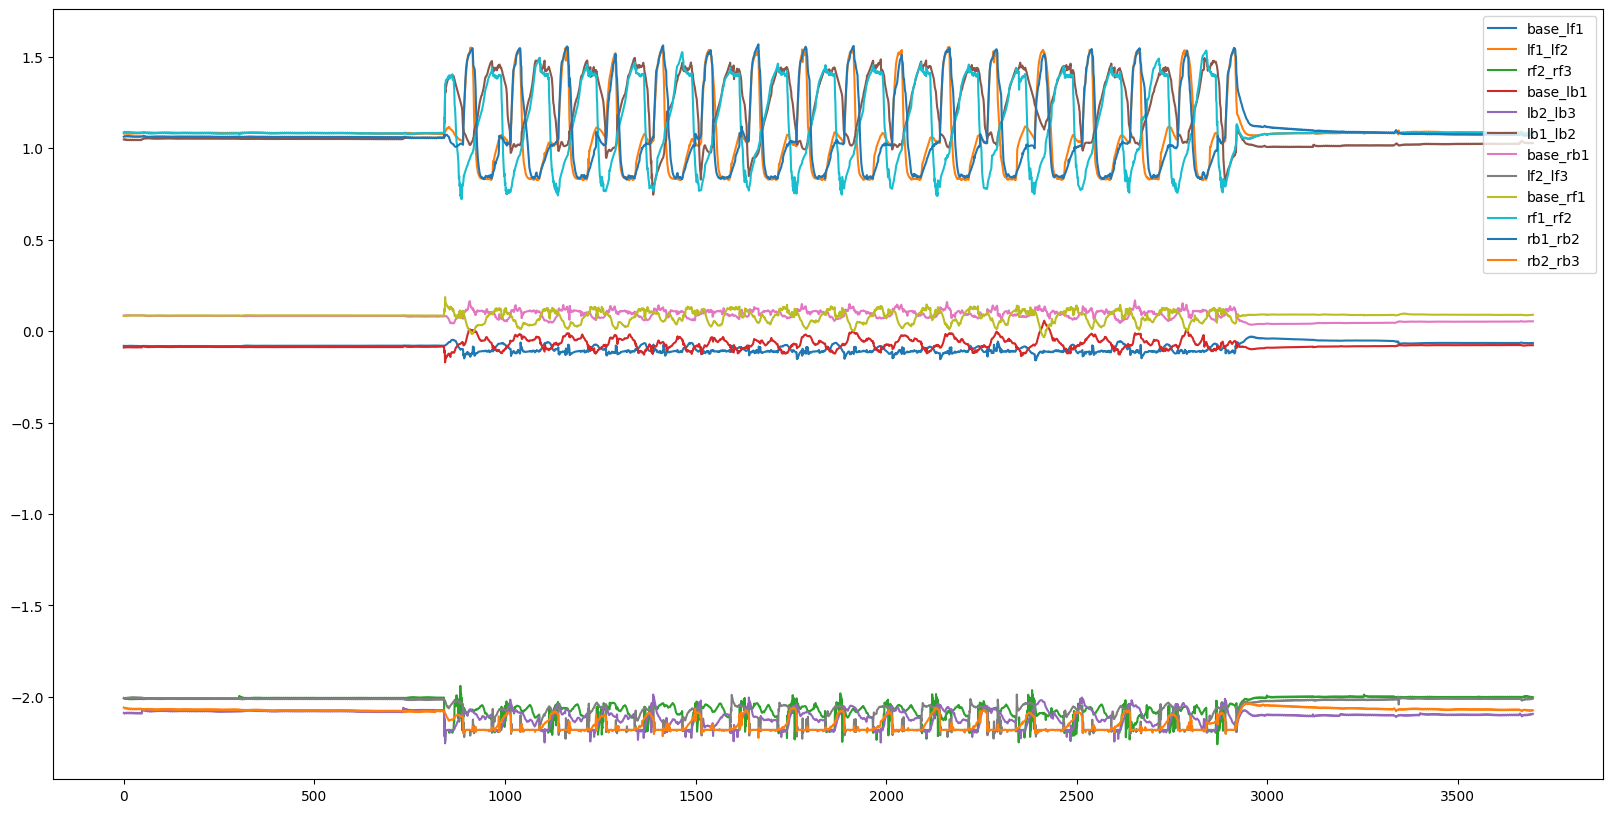

In [7]:
from rosidl_runtime_py.utilities import get_message
from rclpy.serialization import deserialize_message

# get joint_states
gaze_joint_states = pd.read_sql_query("SELECT * FROM messages WHERE topic_id=17", conn)
gaze_data = gaze_joint_states['data'].iloc[0]

def get_joint_names(d):
    return parse_joint(d).name

def parse_joint(d, idx=0):
    # Get the message class from the type string
    msg_type = get_message("sensor_msgs/msg/JointState")
    # Deserialize the message
    msg = deserialize_message(d, msg_type)
    return msg

print(parse_joint(gaze_data))

from matplotlib import pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(20, 10))

for j_id, j_name in enumerate(get_joint_names(gaze_data)):
    value = gaze_joint_states['data'].apply(lambda x: float(parse_joint(x).position[j_id]))
    axes.plot(value, label=j_name)

# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 0))))
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 1))))
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 2))))
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 3))))
plt.legend()
plt.plot()


In [9]:
rviz_data = "../../../ros2_log/pupper_rviz/pupper_rviz_0.db3"
conn = sqlite3.connect(rviz_data)

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

print(tables)

# print topic with id
topics = pd.read_sql_query("SELECT * FROM topics", conn)

# print all without collapsing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print(topics)

       name
0    schema
1  metadata
2    topics
3  messages
    id                                             name  \
0    1                                       /tf_static   
1    2                                              /tf   
2    3                               /robot_description   
3    4                          /base_to_footprint_pose   
4    5                              /events/write_split   
5    6                                   /foot_contacts   
6    7                                   /clicked_point   
7    8                                        /odom/raw   
8    9                                /parameter_events   
9   10                                         /cmd_vel   
10  11                                      /odom/local   
11  12                                          /rosout   
12  13                                     /diagnostics   
13  14                                            /foot   
14  15                                     /initialpose

/tmp/ipykernel_2611629/1581103963.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20c')


sensor_msgs.msg.JointState(header=std_msgs.msg.Header(stamp=builtin_interfaces.msg.Time(sec=1751593186, nanosec=261878583), frame_id=''), name=['base_lf1', 'lf1_lf2', 'lf2_lf3', 'base_rf1', 'rf1_rf2', 'rf2_rf3', 'base_lb1', 'lb1_lb2', 'lb2_lb3', 'base_rb1', 'rb1_rb2', 'rb2_rb3'], position=[-0.08031128346920013, 1.0780668258666992, -1.983426570892334, 0.08031131327152252, 1.0780668258666992, -1.983426570892334, -0.08031128346920013, 1.0780668258666992, -1.983426570892334, 0.08031131327152252, 1.0780668258666992, -1.983426570892334], velocity=[], effort=[])


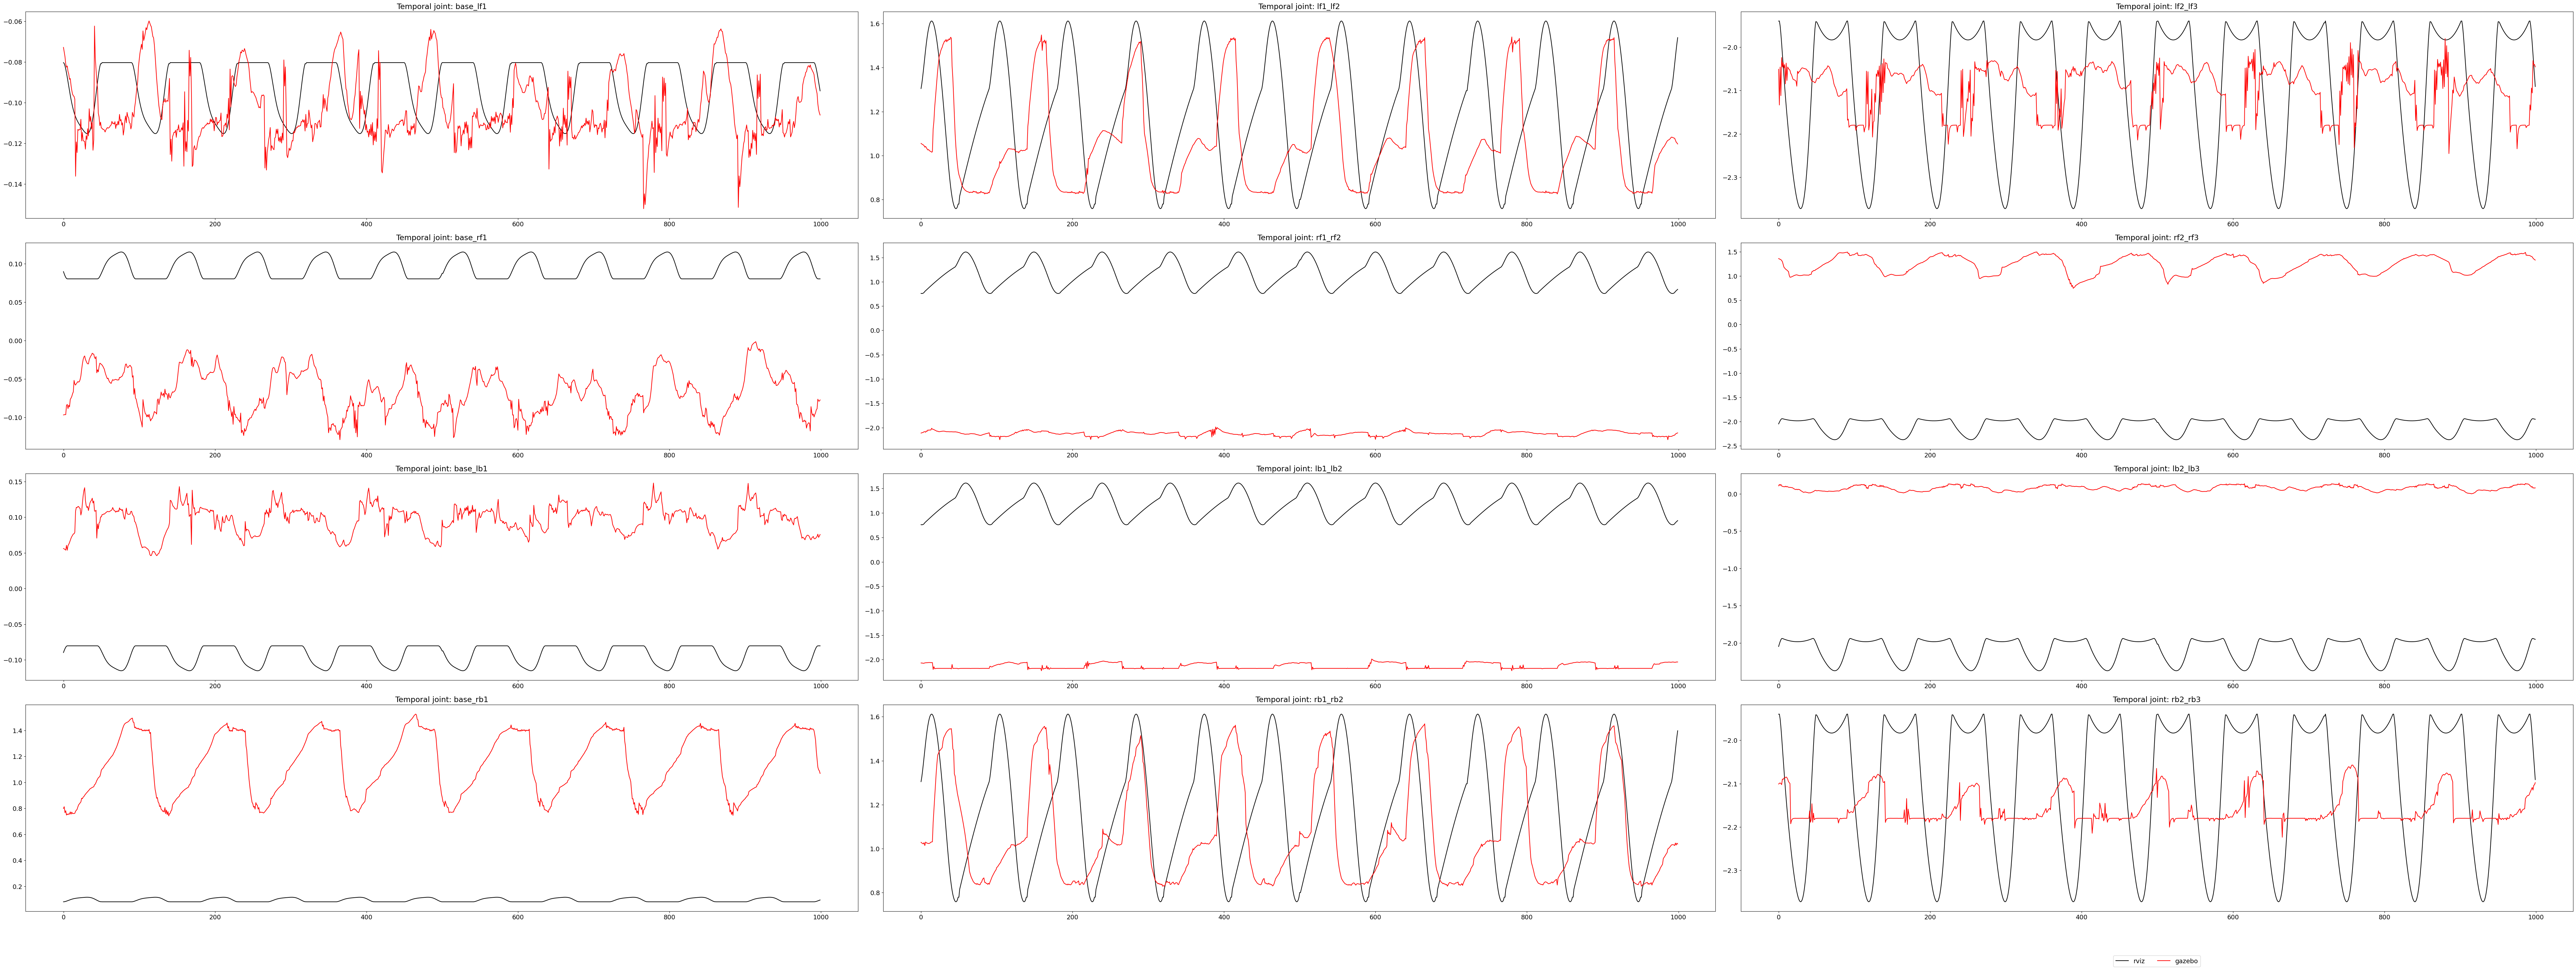

In [15]:
import matplotlib.cm as cm # For colormaps
import numpy as np
# get joint_states
joint_states = pd.read_sql_query("SELECT * FROM messages WHERE topic_id=18", conn)
data = joint_states['data'].iloc[0]

cmap = cm.get_cmap('tab20c')
colors_tab20 = [cmap(i) for i in range(12)]
plt.rcParams.update({'font.size': 14})

def get_joint_names(d):
    return parse_joint(d).name

def parse_joint(d, idx=0):
    # Get the message class from the type string
    msg_type = get_message("sensor_msgs/msg/JointState")
    # Deserialize the message
    msg = deserialize_message(d, msg_type)
    return msg

print(parse_joint(data))

from matplotlib import pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(80, 30))

for j_id, j_name in enumerate(get_joint_names(data)):
    row_id = j_id // 3
    col_id = j_id % 3
    value_gz = gaze_joint_states['data'].apply(lambda x: float(parse_joint(x).position[j_id]))
    value = joint_states['data'].apply(lambda x: float(parse_joint(x).position[j_id]))
    axes[row_id, col_id].set_title("Temporal joint: " + j_name)
    axes[row_id, col_id].plot(np.arange(1000),value[1000:2000], label="rviz", c="black")

    axes[row_id, col_id].plot(np.arange(1000),value_gz[1000:2000], label="gazebo", c="red")


plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=6)
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 0))))
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 1))))
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 2))))
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 3))))

fig.tight_layout()
plt.plot()

plt.savefig("servo_hist.png")

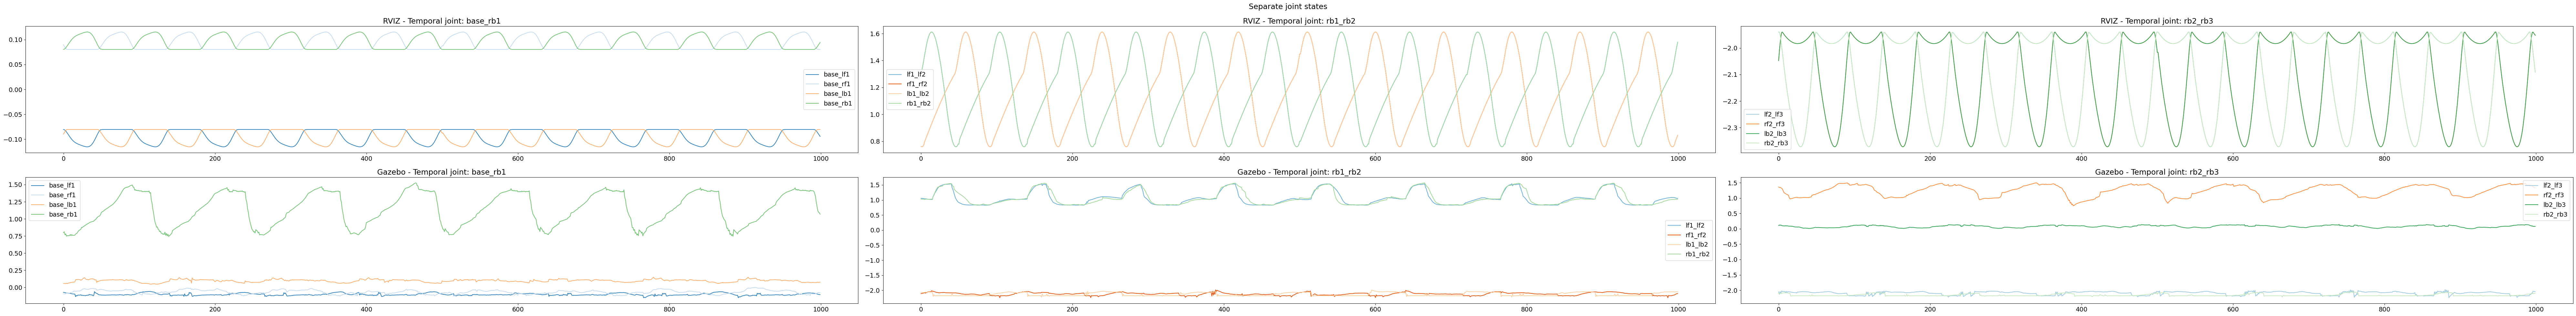

In [33]:
# For relative comparison between joints


fig, axes = plt.subplots(2, 3, figsize=(80, 10))

fig.suptitle("Separate joint states")
for j_id, j_name in enumerate(get_joint_names(data)):
    col_id = j_id % 3
    value_gz = gaze_joint_states['data'].apply(lambda x: float(parse_joint(x).position[j_id]))
    value = joint_states['data'].apply(lambda x: float(parse_joint(x).position[j_id]))
    axes[0, col_id].set_title("RVIZ - Temporal joint: " + j_name)
    axes[0, col_id].plot(np.arange(1000),value[1000:2000], label=j_name, c=colors_tab20[j_id])
    axes[0, col_id].legend()
    
    axes[1, col_id].set_title("Gazebo - Temporal joint: " + j_name)
    axes[1, col_id].plot(np.arange(1000),value_gz[1000:2000], label=j_name, c=colors_tab20[j_id])
    axes[1, col_id].legend()

fig.tight_layout()
plt.plot()
plt.savefig("sep_servo_hist.png")